# Ackley20

The Ackley function is a classical function, proposed by David Ackley, to test the performance of optimization algorithms. Its global minimum is located at the origin where the function value is zero. However, the presence of a huge number of local minima makes the problem very difficult. The computational domain considered is defined as $\Omega =[-5,10]^{d}$ with $d=20$. Two fidelity levels are considered, and given by
\begin{align*}
f^{(1)}(\boldsymbol{x}) &= -20 \exp\left(-0.2 \sqrt{\frac{1}{d}} \|\boldsymbol{x}\|_2 \right)
- \exp\left(\frac{1}{d} \sum_{i=1}^{d} \cos(2\pi x_i)\right)
+ 20 + \exp(1), \\
f^{(0)}(\boldsymbol{x}) &= -22 \exp\left(-0.2 \sqrt{\frac{1.1}{d}} \|\boldsymbol{x}\|_2 \right)
- 0.9 \exp\left(\frac{1}{d} \sum_{i=1}^{d} \cos(2\pi x_i)\right)
+ 20 + \exp(1),\\
\end{align*}
where $f^{(1)}$ is the classical Ackley function. Two constraints are imposed, following : 
\begin{equation*}
c_1(\boldsymbol{x}) = \sum_{i=1}^{20} x_i \leq 0,
\qquad
c_2(\boldsymbol{x}) = \|\boldsymbol{x}\|_2 - 5 \leq 0,
\end{equation*}
the first is a hyperplane constraint, and the second defines a sphere centered at the origin with radius $5$.

## Imports

In [1]:
import sys, os
sys.path.insert(0, os.getcwd()) #equivalent to " export PYTHONPATH="$PWD:$PYTHONPATH" "

In [2]:
from mfscbo.functions import Ackley
from mfscbo.mfscbo_optimization import ScboMfOptimizer
from mfscbo.plot import plot_rhos, plot_noises, plot_bestYs, plot_nbiters, plot_tr_lengths
from mfscbo.utils import eval_fun_unnormalized
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

## Problem setup

In [3]:
# Define torch arguments
torchargs = {
    "device": "cpu",
    "dtype": torch.double
}

In [4]:
dim = 20
# Define evaluation objectives at different fidelities
f0_ = Ackley(dim=dim, fidelity=1, torchargs=torchargs)
f1_ = Ackley(dim=dim, fidelity=2, torchargs=torchargs)

# Define bounds and dimension
bounds = f0_.bounds
dim = bounds.shape[1]

# Convert to maximization problem (SCBO expects maximization) and unnormalize
f0 = lambda x: -eval_fun_unnormalized(x, f0_, bounds)
f1 = lambda x: -eval_fun_unnormalized(x, f1_, bounds)
eval_objectives = [f0, f1]

In [5]:
# Define constraints (use bilog transformation for the constraints)
def constraints(x) :
    c1 = torch.sum(x, dim=1)
    c2 = torch.norm(x, dim=1) - 5
    res = torch.stack([c1, c2]).transpose(0, 1)
    return res

def log_constraints(x) :
    c = constraints(x)
    return torch.sign(c) * torch.log(1 + torch.abs(c))

def eval_constraints(x) :
    return eval_fun_unnormalized(x, log_constraints, bounds)

In [6]:
# Define number of initial points, rhos, and costs for each fidelity
n_pts = [72, 8] #total 4*dim = 72 +8
rhos = [1, 1]
costs = [1, 20]

## Optimization

In [7]:
# Initialize and run the SCBO optimizer
optimizer = ScboMfOptimizer(
    eval_objectives=eval_objectives,
    constraints=eval_constraints,
    rhos=rhos,
    costs=costs,
    dim=dim,
    n_pts=n_pts,
    bounds=bounds,
    type_of_batch="parallel",
    type_of_centering="evaluated",
    torchargs=torchargs,
    restart=True,
    test=True,  # Predictive mode
)
optimizer.initialize()
optimizer.optimize(max_cost=4000, batch_size=8, path="results/Ackley20", verbose=True)

Starting MF-SCBO optimization...
Max cost : 4000
Batch size : 8
Path : results/Ackley20

=================================================================================================================== Parameters for MF-SCBO Optimization ====================================================================================================================
____________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________
| Parameter         | Value                                                                                                                                                                                                                                                |
--------------------------------------------------------------------------------------------------------

(tensor([-0.8596,  0.2239, -0.5837, -0.1957, -0.5847,  0.1005, -0.1557,  0.4482,
         -0.2451, -0.7041, -0.3918, -0.5726,  0.8493,  0.3067, -0.1546,  0.2381,
         -0.1101,  0.2087,  0.7571,  0.5163], dtype=torch.float64),
 -3.5985739292850707)

## Post process

In [8]:
# Load results
data = np.load("results/Ackley20/MFSCBO_data.npz", allow_pickle=True)
gps_info = data["gps_info"]
iterations = data["iterations"]
xvalues = data["cost_iter"]
bestY = -data["best_Y"] #for minimization plot
best_C = data["best_C"]
nbiters = data["nb_iter"]
tr_lengths = data["trust_region_lengths"]

In [9]:
# Post-process bestY when constraints are not respected 
best_violated_C = np.sum(np.maximum(0, best_C), axis=1)
bestY = np.array(bestY, dtype=np.float64)
running_max = np.max(bestY)
bestY = np.where(best_violated_C > 0, running_max, bestY)

# Post-process rhos
rhos = [[1] for _ in range(len(gps_info)-1)]  # no rho for fidelity 0
for fid in range(1, len(gps_info)):
    for it in range(len(iterations)-1):
        rhos[fid-1].append(gps_info[fid][it]["rho"])

# Post-process noises
noises = [[] for _ in range(len(gps_info))]
for fid in range(len(gps_info)):
    for it in range(len(iterations)-1):
        noises[fid].append(gps_info[fid][it]["noise"])

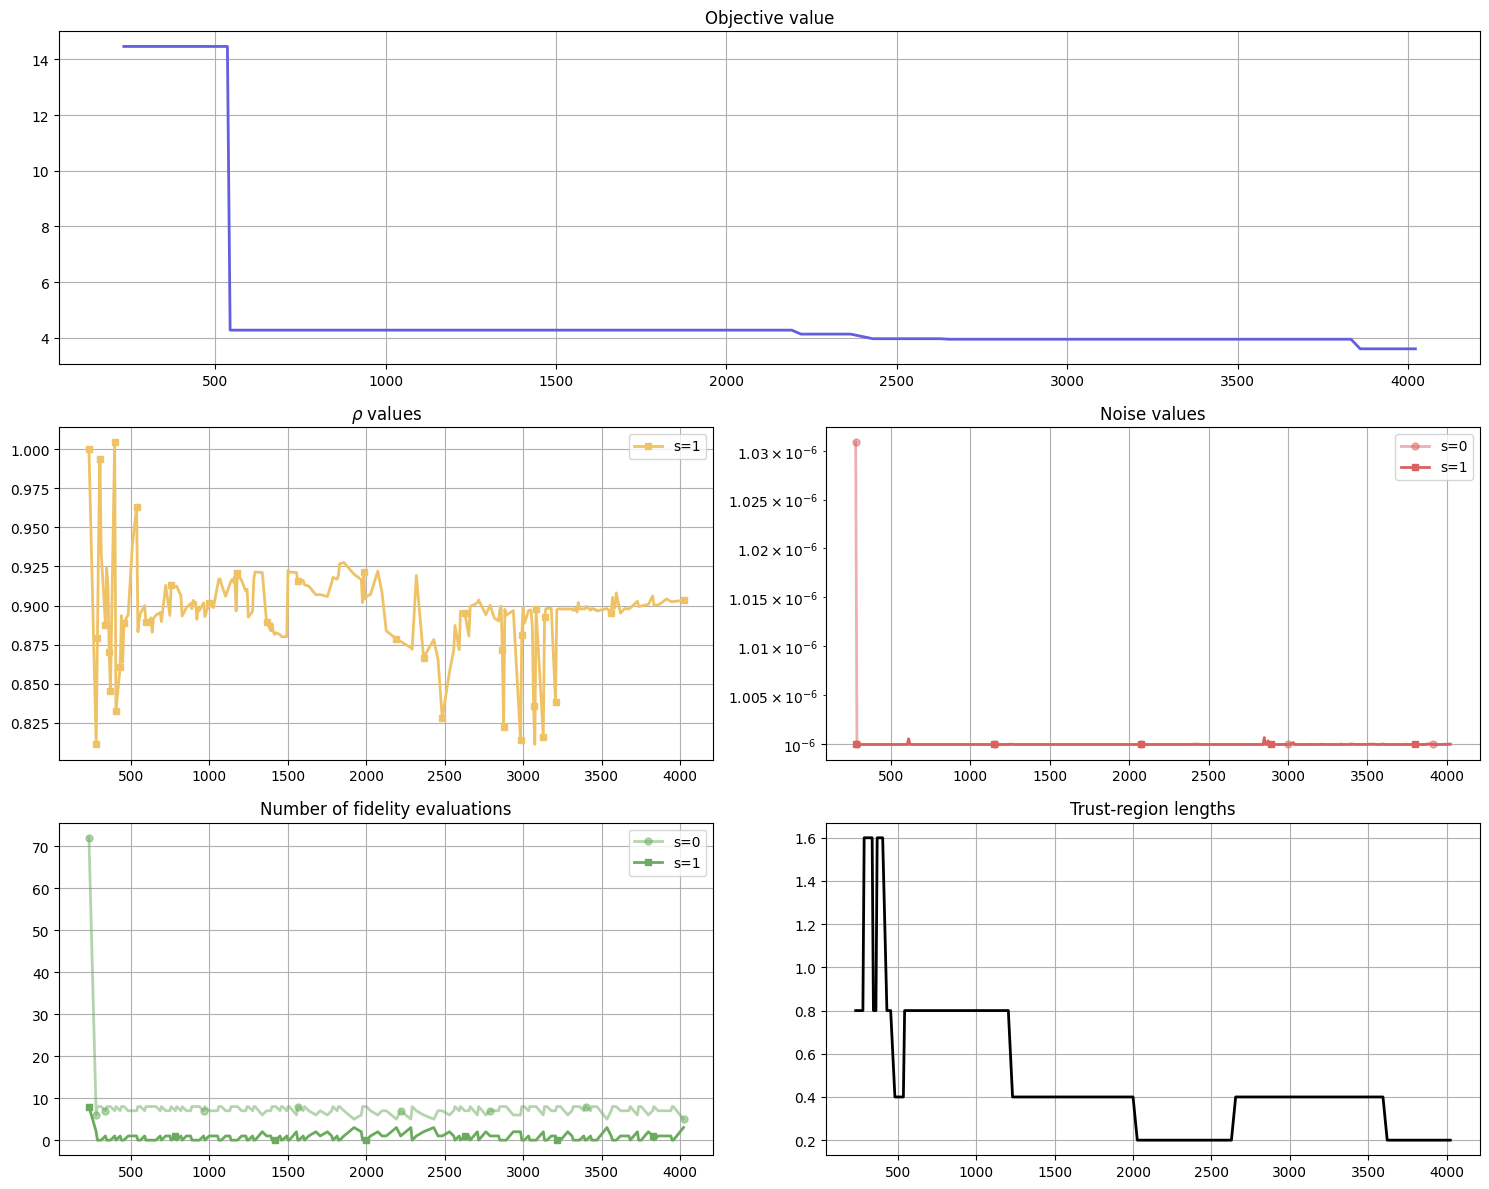

In [10]:
# Plot results
fig = plt.figure(figsize=(15, 12))
gs = GridSpec(3, 2, figure=fig)
ax1 = fig.add_subplot(gs[0, :])
ax2 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[1, 1])
ax4 = fig.add_subplot(gs[2, 0])
ax5 = fig.add_subplot(gs[2, 1])

plot_bestYs(bestY, xvalues, ax=ax1)
plot_rhos(rhos, xvalues, ax=ax2)
plot_noises(noises, xvalues[1:], ax=ax3)
plot_nbiters(nbiters, xvalues, ax=ax4)
plot_tr_lengths(tr_lengths, xvalues, ax=ax5)

# Set titles, legends, and grids
ax1.set_title("Objective value")
ax1.grid()
ax2.set_title(r"$\rho$ values")
ax2.legend()
ax2.grid()
ax3.set_title("Noise values")
ax3.legend()
ax3.grid()
ax3.set_yscale("log")
ax4.set_title("Number of fidelity evaluations")
ax4.legend()
ax4.grid()
ax5.set_title("Trust-region lengths")
ax5.grid()

plt.tight_layout()
plt.savefig("results/Ackley20/MFSCBO_plots.pdf")
plt.show()